# Lab 9a: PCA for Face Recognition
    
Following the demo for this unit, we will explore further the use of PCA for feature dimension reduction for classification. We will use a 2-layer neural net on the PCA coefficients. We will practice optimizing the classificaiton parameters (the number of PCA components and the number of hidden nodes in the NN classifier). We will furthermore compare this approach with using convolutional neural net on raw images.

Through the lab, you will learn to:

* Perform PCA on the a face dataset to find the PC components
* Evaluate the effect of using different nubmer of principle components for data representation and classification.
* Optimize the number of PC coefficients and classifier parameters together to maximize classification accuracy.
* Understand the impact of training data size on the feature and classification method selection.


In [15]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [16]:
from sklearn.datasets import fetch_lfw_people

lfw_people = fetch_lfw_people(min_faces_per_person=100, resize=0.4)



In [17]:
# Save the face images in a datamatrix X and the labels and corresponding names in a datamatrix y and target_names
X = lfw_people.images           # shape: (n_samples, h, w)
y = lfw_people.target           # shape: (n_samples,)
target_names = lfw_people.target_names  # array of names

# Determine the number of samples and the image size
n_samples, h, w = X.shape
print(f"Number of samples: {n_samples}")
print(f"Image size: {h}x{w}")

# Determine the number of different faces (number of classes)
n_classes = target_names.shape[0]
print(f"Number of classes (different faces): {n_classes}")

Number of samples: 1140
Image size: 50x37
Number of classes (different faces): 5


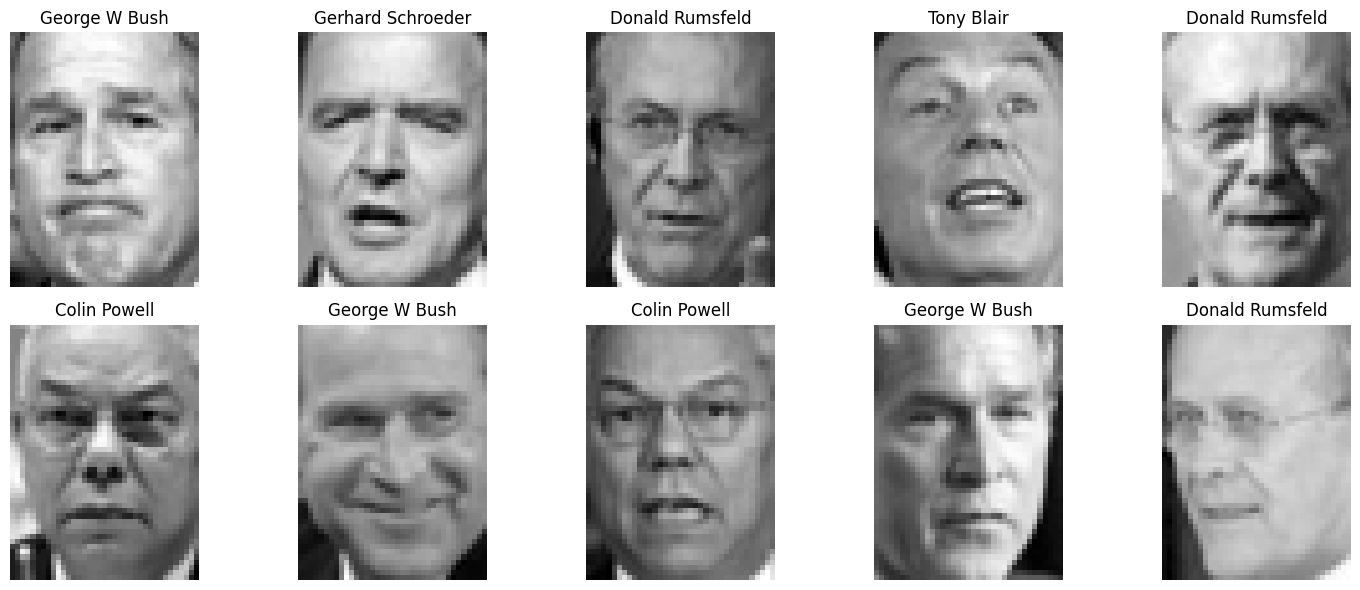

In [18]:
# Plot some sample images to make sure your data load is correct
images = X[:10]
labels = y[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(images[i], cmap='gray')
    axes[i].set_title(target_names[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()



In [19]:
# Split the data into a training set and test set with 50% data for training. 
# Use "stratify" option to make sure the training data and test data have same 
# proportion of images from different faces
# print the number of samples in the training data

# TO DO 
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.5, stratify=y)
print(f"Number of samples in the training data: {len(train_X)}")
print(f"Number of samples in the test data: {len(test_X)}")


Number of samples in the training data: 570
Number of samples in the test data: 570


In [20]:
# Flatten images to 2D: (n_samples, h*w)
train_X_flat = train_X.reshape(len(train_X), -1)

# Remove the mean
data_mean = np.mean(train_X_flat, axis=0)
train_X_centered = train_X_flat - data_mean

# Compute SVD and get principal components
# Vt contains PCs as rows, transpose to get columns
U, S, Vt = np.linalg.svd(train_X_centered, full_matrices=False)
V = Vt.T  # Principal components as columns

# Rescale so coefficients have unit variance
# Standard approach: normalize by sqrt(n-1) to get unit variance coefficients
# The coefficients will be: Z = X_centered @ V_normalized
# where V_normalized = V / sqrt(eigenvalues) = V * sqrt(n-1) / S
V = V * np.sqrt(len(train_X) - 1) / S[np.newaxis, :]

n_pcs = V.shape[1]
print(f"Total number of PCs: {n_pcs}")

Total number of PCs: 570


First let us construct a 2-layer neural net classifier that uses npc= 100 PCA coefficients to classify the faces.  Set up your training and testing data to contain npc PCA coefficients using the previously determined principle components. You should directly use matrix multiplication (i.e. projecting original data to the first 100 principle components you found previously) to find the coefficients rather then using the pca.transform( ) method.


In [21]:
from keras.models import Sequential
from keras.layers import Dense
import time

npc = 100

# Flatten and center test data using training mean
print("Flattening test data...")
test_X_flat = test_X.reshape(len(test_X), -1)
print(f"test_X_flat shape: {test_X_flat.shape}")
print(f"data_mean shape: {data_mean.shape}")

test_X_centered = test_X_flat - data_mean
print(f"test_X_centered shape: {test_X_centered.shape}")

# Project data onto first npc principal components using matrix multiplication
print(f"\nProjecting data onto first {npc} PCs...")
print(f"train_X_centered shape: {train_X_centered.shape}")
print(f"V shape: {V.shape}")
train_X_pca = train_X_centered @ V[:, :npc]
test_X_pca = test_X_centered @ V[:, :npc]
print(f"train_X_pca shape: {train_X_pca.shape}")
print(f"test_X_pca shape: {test_X_pca.shape}")
print(f"train_y shape: {train_y.shape}")

# Set up and compile NN model
print("\nSetting up model...")
model = Sequential([
    Dense(100, activation='relu', input_shape=(npc,)),
    Dense(n_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(f"Model summary:")
model.summary()

# Fit model and evaluate
print(f"\nStarting training with {len(train_X_pca)} samples, batch_size=100...")
print(f"Number of batches per epoch: {len(train_X_pca) // 100}")
print(f"Data types: train_X_pca={train_X_pca.dtype}, train_y={train_y.dtype}")

start_time = time.time()
history = model.fit(train_X_pca, train_y, epochs=10, batch_size=100, 
                    validation_data=(test_X_pca, test_y), verbose=1)
elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

test_accuracy = model.evaluate(test_X_pca, test_y, verbose=0)[1]
print(f"\nTest accuracy: {test_accuracy:.4f}")


Flattening test data...
test_X_flat shape: (570, 1850)
data_mean shape: (1850,)
test_X_centered shape: (570, 1850)

Projecting data onto first 100 PCs...
train_X_centered shape: (570, 1850)
V shape: (1850, 570)
train_X_pca shape: (570, 100)
test_X_pca shape: (570, 100)
train_y shape: (570,)

Setting up model...
Model summary:


/Users/willem/Library/CloudStorage/GoogleDrive-wdn2012@nyu.edu/My Drive/F2025/introml/introml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,605 (41.43 KB)

 Trainable params: 10,605 (41.43 KB)

 Non-trainable params: 0 (0.00 B)


Starting training with 570 samples, batch_size=100...
Number of batches per epoch: 5
Data types: train_X_pca=float64, train_y=int64
Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1825 - loss: 1.9345 - val_accuracy: 0.2211 - val_loss: 1.7814
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2965 - loss: 1.6208 - val_accuracy: 0.3298 - val_loss: 1.5676
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4298 - loss: 1.3828 - val_accuracy: 0.4228 - val_loss: 1.4015
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5456 - loss: 1.2015 - val_accuracy: 0.5070 - val_loss: 1.2783
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6263 - loss: 1.0638 - val_accuracy: 0.5632 - val_loss: 1.1847
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6719 - loss: 0.9498 - val_accuracy: 0.5895 - val_loss: 1.1078
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7316 - loss: 0.8544 - val_accuracy: 0.6211 - val_loss: 1.039

Now set up and compile a NN model with number of hidden nodes nnode=100 and a output layer, and then fit the model to the training data. Use 'relu' for the activation for the hidden layer and use 'softmax' for the output layer. Using `sparse_categorical_crossentropy` for the loss. Use `accuracy` as the metrics. You can choose to do a small number of epochs (=10) with batch size =100.  Determine the accuracy on the validation set.

In [22]:
from keras.models import Sequential
from keras.layers import Dense

npc = 100
nnode = 100

# Set up and compile NN model
model = Sequential([
    Dense(nnode, activation='relu', input_shape=(npc,)),
    Dense(n_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit model to training data
history = model.fit(train_X_pca, train_y, epochs=10, batch_size=100, 
                    validation_data=(test_X_pca, test_y), verbose=1)

# Determine accuracy on validation set
val_accuracy = model.evaluate(test_X_pca, test_y, verbose=0)[1]
print(f"\nValidation accuracy: {val_accuracy:.4f}")


Epoch 1/10


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2368 - loss: 1.8993 - val_accuracy: 0.2737 - val_loss: 1.7586
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3526 - loss: 1.5800 - val_accuracy: 0.3684 - val_loss: 1.5488
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4719 - loss: 1.3435 - val_accuracy: 0.4544 - val_loss: 1.3970
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5404 - loss: 1.1731 - val_accuracy: 0.5070 - val_loss: 1.2861
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6158 - loss: 1.0398 - val_accuracy: 0.5614 - val_loss: 1.1996
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6825 - loss: 0.9272 - val_accuracy: 0.6000 - val_loss: 1.1243
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7421 - loss: 0.8292 - val_accuracy: 0.6246 - val_loss: 1.0568
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7825 - loss: 0.7412 - val_accuracy: 0.6491 - val_loss: 0.9965
Epoch 9/10
6/6 ━━━

Now try to identify the best number of PCs and the best number of hidden nodes in the NN classifer that can achieve the highest validation accuracy. 
You can set the range of PCs and nubmer of hidden nodes as below.

nnodes = [50,100,150,200, 250],
npcs = [50,100,150,200]


In [23]:
nnodes = [50, 100, 150, 200, 250]
npcs = [50, 100, 150, 200]

# Set up an array to store accuracy for different nnode and npcs
accuracy_grid = np.zeros((len(nnodes), len(npcs)))



In [24]:
# Loop through the combinations to find the accuracy for each combination
for i, nnode in enumerate(nnodes):
    for j, npc in enumerate(npcs):
        print(f"\nTesting nnode={nnode}, npc={npc}")
        
        # Project data onto first npc principal components
        train_X_pca_subset = train_X_centered @ V[:, :npc]
        test_X_pca_subset = test_X_centered @ V[:, :npc]
        
        # Set up and fit model
        model = Sequential([
            Dense(nnode, activation='relu', input_shape=(npc,)),
            Dense(n_classes, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
        # Fit model
        model.fit(train_X_pca_subset, train_y, epochs=10, batch_size=100, 
                 validation_data=(test_X_pca_subset, test_y), verbose=0)
        
        # Evaluate and store validation accuracy
        val_accuracy = model.evaluate(test_X_pca_subset, test_y, verbose=0)[1]
        accuracy_grid[i, j] = val_accuracy
        print(f"Validation accuracy: {val_accuracy:.4f}") 



Testing nnode=50, npc=50
Validation accuracy: 0.5719

Testing nnode=50, npc=100
Validation accuracy: 0.6316

Testing nnode=50, npc=150
Validation accuracy: 0.6088

Testing nnode=50, npc=200
Validation accuracy: 0.5930

Testing nnode=100, npc=50
Validation accuracy: 0.7158

Testing nnode=100, npc=100
Validation accuracy: 0.6982

Testing nnode=100, npc=150
Validation accuracy: 0.6912

Testing nnode=100, npc=200
Validation accuracy: 0.6895

Testing nnode=150, npc=50
Validation accuracy: 0.7579

Testing nnode=150, npc=100
Validation accuracy: 0.7474

Testing nnode=150, npc=150
Validation accuracy: 0.7526

Testing nnode=150, npc=200
Validation accuracy: 0.7579

Testing nnode=200, npc=50
Validation accuracy: 0.7807

Testing nnode=200, npc=100
Validation accuracy: 0.7649

Testing nnode=200, npc=150
Validation accuracy: 0.7561

Testing nnode=200, npc=200
Validation accuracy: 0.7474

Testing nnode=250, npc=50
Validation accuracy: 0.8053

Testing nnode=250, npc=100
Validation accuracy: 0.8000



In [33]:
# Determine the npc and nnode that provides the highest validation accuracy
highest_accuracy = np.max(accuracy_grid)
best_indices = np.unravel_index(np.argmax(accuracy_grid), accuracy_grid.shape)
best_nnode_idx, best_npc_idx = best_indices
best_nnode = nnodes[best_nnode_idx]
best_npc = npcs[best_npc_idx]

print(f"Best validation accuracy: {highest_accuracy:.4f}")
print(f"Best nnode: {best_nnode}")
print(f"Best npc: {best_npc}")


Best validation accuracy: 0.8053
Best nnode: 250
Best npc: 50


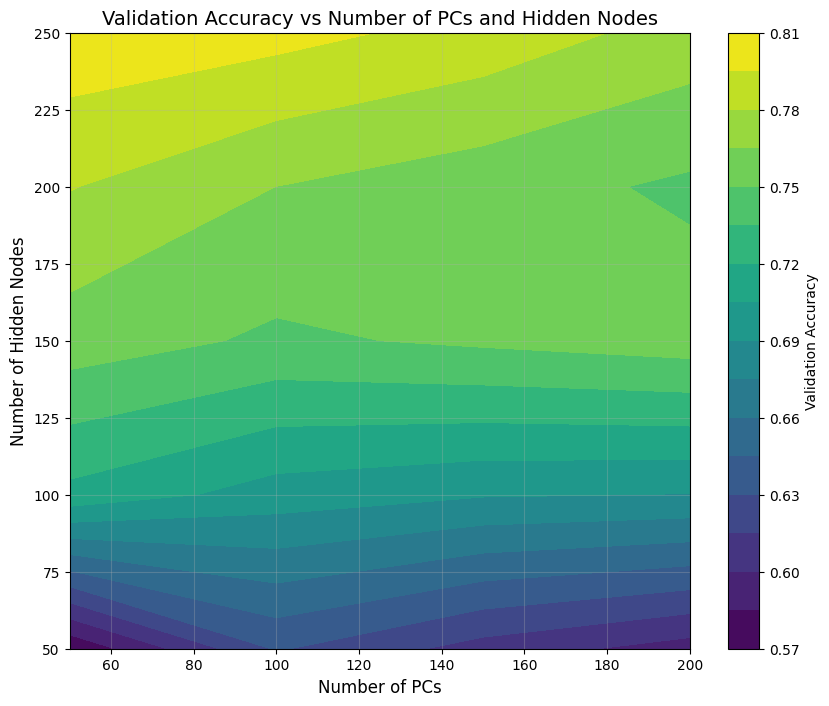

In [34]:
# Produce a contour plot of the accuracy using different nnode and npc combinations
plt.figure(figsize=(10, 8))
contour = plt.contourf(npcs, nnodes, accuracy_grid, levels=20, cmap='viridis')
plt.colorbar(contour, label='Validation Accuracy')
plt.xlabel('Number of PCs', fontsize=12)
plt.ylabel('Number of Hidden Nodes', fontsize=12)
plt.title('Validation Accuracy vs Number of PCs and Hidden Nodes', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()


## Now let us compare the PCA+NN with applying a CNN on the raw image data only. 

Note that you should scale your image data to between 0 and 1. And you should reshape your training and testing data according to image width and height


In [35]:
# Scale image data to between 0 and 1
# Check if data is already normalized or needs scaling
print(f"Original train_X range: [{train_X.min():.2f}, {train_X.max():.2f}]")
if train_X.max() > 1.0:
    # Data is in [0, 255] range, need to scale
    train_X_cnn = train_X.astype('float32') / 255.0
    test_X_cnn = test_X.astype('float32') / 255.0
else:
    # Data is already in [0, 1] range
    train_X_cnn = train_X.astype('float32')
    test_X_cnn = test_X.astype('float32')

# Reshape data for CNN: (n_samples, height, width, channels)
# For grayscale images, add channel dimension
train_X_cnn = train_X_cnn.reshape(train_X_cnn.shape[0], h, w, 1)
test_X_cnn = test_X_cnn.reshape(test_X_cnn.shape[0], h, w, 1)

print(f"train_X_cnn shape: {train_X_cnn.shape}")
print(f"test_X_cnn shape: {test_X_cnn.shape}")
print(f"Scaled data range: [{train_X_cnn.min():.2f}, {train_X_cnn.max():.2f}]")


Original train_X range: [0.00, 1.00]
train_X_cnn shape: (570, 50, 37, 1)
test_X_cnn shape: (570, 50, 37, 1)
Scaled data range: [0.00, 1.00]


In [36]:
from keras.layers import Conv2D, MaxPooling2D, Flatten

# Set up a CNN model
model_cnn = Sequential([
    Conv2D(16, (5, 5), activation='relu', input_shape=(h, w, 1)),
    MaxPooling2D(pool_size=(2, 2), strides=2),
    Conv2D(16, (5, 5), activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),
    Flatten(),
    Dense(200, activation='relu'),
    Dense(n_classes, activation='softmax')
])

# Print model summary to verify structure
model_cnn.summary()

# Compile the model
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) 



Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 46, 33, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 12, 16)     │         6,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 864)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 200)            │       173,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 5)              │         1,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,837 (706.39 KB)

 Trainable params: 180,837 (706.39 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Fit the model using batch size=100, epochs = 40
history_cnn = model_cnn.fit(train_X_cnn, train_y, epochs=40, batch_size=100,
                            validation_data=(test_X_cnn, test_y), verbose=1)

# Print the accuracy on the validation set
val_accuracy_cnn = model_cnn.evaluate(test_X_cnn, test_y, verbose=0)[1]
print(f"\nCNN Validation accuracy: {val_accuracy_cnn:.4f}") 


Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4123 - loss: 1.4669 - val_accuracy: 0.4649 - val_loss: 1.4004
Epoch 2/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4649 - loss: 1.4085 - val_accuracy: 0.4649 - val_loss: 1.3859
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4649 - loss: 1.3821 - val_accuracy: 0.4649 - val_loss: 1.3654
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4649 - loss: 1.3532 - val_accuracy: 0.4649 - val_loss: 1.3326
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4649 - loss: 1.3150 - val_accuracy: 0.5368 - val_loss: 1.2961
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5070 - loss: 1.2688 - val_accuracy: 0.5439 - val_loss: 1.2204
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5614 - loss: 1.1869 - val_accuracy: 0.5316 - val_loss: 1.1661
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5702 - loss: 1.1188 - val_accuracy: 0.5649 - val_loss: 1.1146


How do the result compared with the PCA+NN method? (If you did right, they should be similar, with PCA+NN being slightly better. If you used more training data (e.g. 75%) and you trained the CNN with more epochs, CNN method may get better). 

A: The new method gave a validation accuracy of 0.8368, slightly better than the 0.8053 that we got before.

## Repeat the above using a small dataset

Instead of using 50% of the total data for training, let us assume you have only 10% of the total data for training. Repeat both the PCA+NN and the CNN method, to see which one gives you better results. 

Note that with only 10% data for training, the range of the npc has to be set to be below the total number of training samples. 

For the CNN model, because you have small number of training samples, you cannot train a network with a large number of parameters reliably. Instead of producing 16 channels for each of the two conv2D layers, configure the model to produce only 8 channels each. 

In [38]:
# Split data with 10% for training
train_X_small, test_X_small, train_y_small, test_y_small = train_test_split(
    X, y, test_size=0.9, stratify=y)
print(f"Small training set size: {len(train_X_small)}")
print(f"Small test set size: {len(test_X_small)}")

# ===== PCA + NN with small dataset =====
# Flatten and center training data
train_X_small_flat = train_X_small.reshape(len(train_X_small), -1)
data_mean_small = np.mean(train_X_small_flat, axis=0)
train_X_small_centered = train_X_small_flat - data_mean_small

# Compute SVD and get principal components
U_small, S_small, Vt_small = np.linalg.svd(train_X_small_centered, full_matrices=False)
V_small = Vt_small.T
V_small = V_small * np.sqrt(len(train_X_small) - 1) / S_small[np.newaxis, :]

# Prepare test data
test_X_small_flat = test_X_small.reshape(len(test_X_small), -1)
test_X_small_centered = test_X_small_flat - data_mean_small

# Use smaller npc range (below number of training samples)
npc_small = 50  # Use fewer PCs for small dataset
train_X_small_pca = train_X_small_centered @ V_small[:, :npc_small]
test_X_small_pca = test_X_small_centered @ V_small[:, :npc_small]

# Train NN with small dataset
nnode_small = 100
model_small_pca = Sequential([
    Dense(nnode_small, activation='relu', input_shape=(npc_small,)),
    Dense(n_classes, activation='softmax')
])
model_small_pca.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_small_pca.fit(train_X_small_pca, train_y_small, epochs=10, batch_size=100,
                   validation_data=(test_X_small_pca, test_y_small), verbose=0)
val_accuracy_small_pca = model_small_pca.evaluate(test_X_small_pca, test_y_small, verbose=0)[1]
print(f"\nPCA+NN (small dataset) Validation accuracy: {val_accuracy_small_pca:.4f}")

# ===== CNN with small dataset =====
# Scale and reshape data (check if already normalized)
if train_X_small.max() > 1.0:
    train_X_small_cnn = train_X_small.astype('float32') / 255.0
    test_X_small_cnn = test_X_small.astype('float32') / 255.0
else:
    train_X_small_cnn = train_X_small.astype('float32')
    test_X_small_cnn = test_X_small.astype('float32')
train_X_small_cnn = train_X_small_cnn.reshape(train_X_small_cnn.shape[0], h, w, 1)
test_X_small_cnn = test_X_small_cnn.reshape(test_X_small_cnn.shape[0], h, w, 1)

# CNN with 8 channels instead of 16
model_small_cnn = Sequential([
    Conv2D(8, (5, 5), activation='relu', input_shape=(h, w, 1)),
    MaxPooling2D(pool_size=(2, 2), strides=2),
    Conv2D(8, (5, 5), activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),
    Flatten(),
    Dense(200, activation='relu'),
    Dense(n_classes, activation='softmax')
])
model_small_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_small_cnn.fit(train_X_small_cnn, train_y_small, epochs=40, batch_size=100,
                   validation_data=(test_X_small_cnn, test_y_small), verbose=0)
val_accuracy_small_cnn = model_small_cnn.evaluate(test_X_small_cnn, test_y_small, verbose=0)[1]
print(f"CNN (small dataset) Validation accuracy: {val_accuracy_small_cnn:.4f}")

print(f"\nComparison:")
print(f"  PCA+NN: {val_accuracy_small_pca:.4f}")
print(f"  CNN:    {val_accuracy_small_cnn:.4f}")

Small training set size: 114
Small test set size: 1026


/Users/willem/Library/CloudStorage/GoogleDrive-wdn2012@nyu.edu/My Drive/F2025/introml/introml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



PCA+NN (small dataset) Validation accuracy: 0.4269


/Users/willem/Library/CloudStorage/GoogleDrive-wdn2012@nyu.edu/My Drive/F2025/introml/introml/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN (small dataset) Validation accuracy: 0.5175

Comparison:
  PCA+NN: 0.4269
  CNN:    0.5175


Q: How does CNN compare with PCA+NN with the small training set? Why?

A: CNN does much better, almost 10% better. I think this is probably because CNN uses max pooling, which limits the parameters which would be better for less data. Only using 8 channels as well aslo avoids overfitting. PCA doesn't do as well wioth less data because it can't properly choose the best features so could get unlucky with what it selects.